In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

C:\Users\matth\AppData\Local\Temp\ipykernel_12120\2629933840.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=outcome_colors)


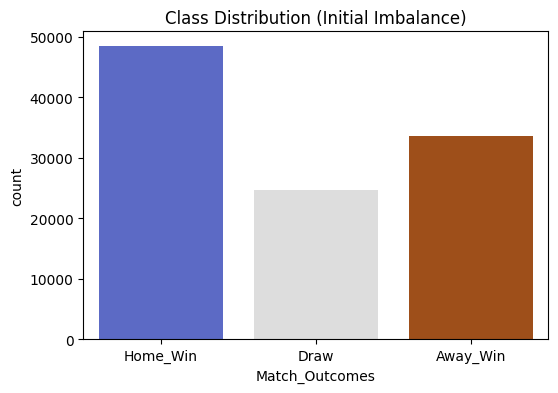

In [10]:
# --- 1. DATA PREPARATION & BALANCED FEATURE ENGINEERING ---
df = pd.read_csv('../data/v2/Final_DataSet_All_Fixed.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Filter for in-play data
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# FEATURE ENGINEERING: Reducing Score Dominance
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Total_Goals'] = df_mod['Home_Score'] + df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time', 'Score_Diff', 'Total_Goals', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
            'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']
X = df_mod[features]
y = df_mod['Match_Outcomes']

# Define universal color palette for consistency across plots - matches coolwarm
outcome_colors = {'Home_Win': "#4b5dd6", 'Away_Win': "#b44a04", 'Draw': "#dddddd8f"}

# Visualizing Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette=outcome_colors)
plt.title("Class Distribution (Initial Imbalance)")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


--- Stage 1: Running Baseline Model ---


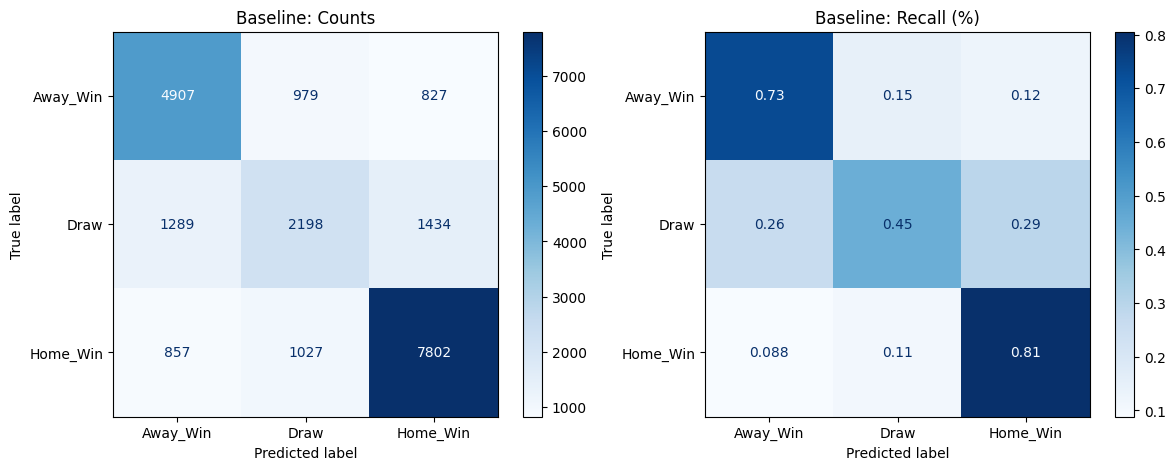

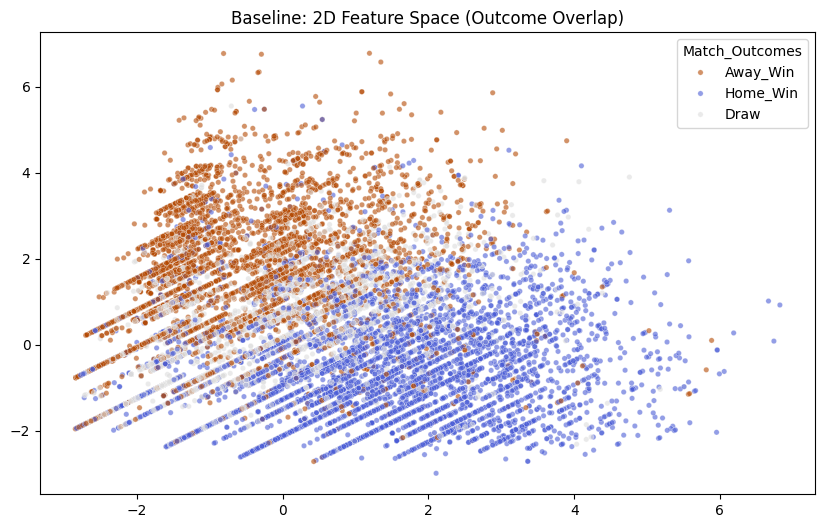


REASONING FOR NEXT STEP:
The baseline model shows heavy overlap, where 'Draw' points are mathematically
drowned out by the density of Wins. We move to SMOTE to populate the Draw
neighborhood, forcing k-NN to recognize minority class patterns.


In [11]:
# STAGE 1: BASELINE MODEL (PCA + k-NN, No SMOTE)
# =================================================================
print("--- Stage 1: Running Baseline Model ---")
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)), # Used for 2D visualization
    ('knn', KNeighborsClassifier(n_neighbors=15))
])
base_pipeline.fit(X_train, y_train)
y_pred_base = base_pipeline.predict(X_test)

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap='Blues', ax=ax[0])
ax[0].set_title("Baseline: Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, cmap='Blues', normalize='true', ax=ax[1])
ax[1].set_title("Baseline: Recall (%)")
plt.show()

# Baseline Cluster Visualization
X_test_pca_base = base_pipeline.named_steps['pca'].transform(base_pipeline.named_steps['scaler'].transform(X_test))
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_pca_base[:, 0], y=X_test_pca_base[:, 1], hue=y_test, 
                palette=outcome_colors, s=15, alpha=0.6)
plt.title("Baseline: 2D Feature Space (Outcome Overlap)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline model shows heavy overlap, where 'Draw' points are mathematically")
print("drowned out by the density of Wins. We move to SMOTE to populate the Draw")
print("neighborhood, forcing k-NN to recognize minority class patterns.")


--- Stage 2: Running SMOTE-Optimized Model ---


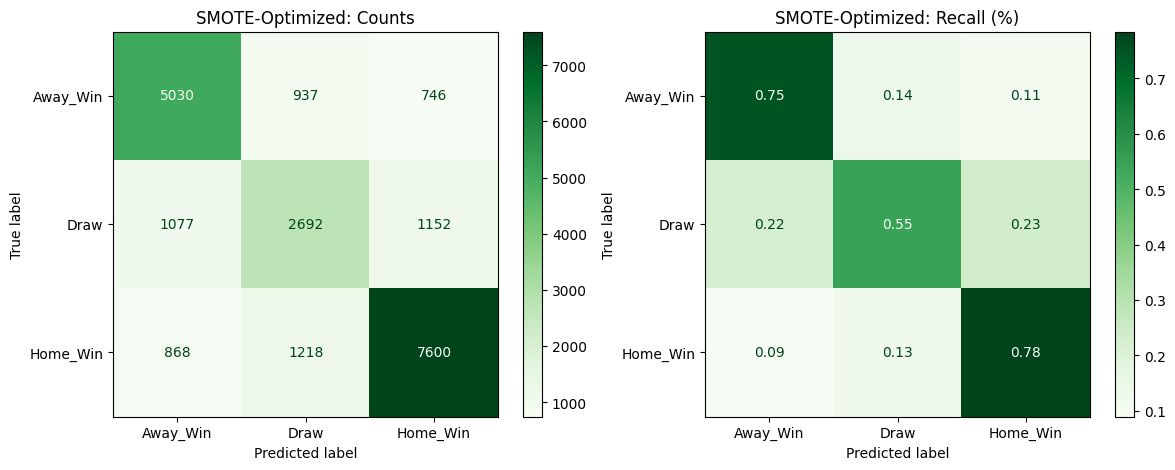

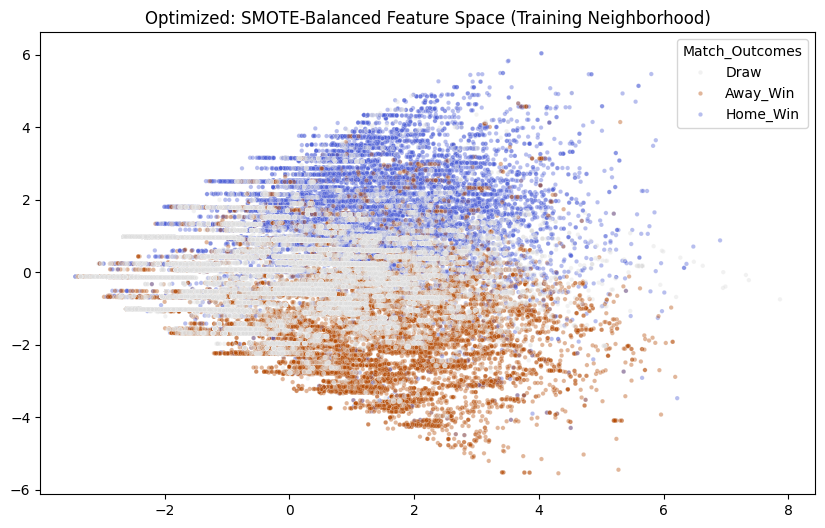


WHAT CHANGED:
By using SMOTE and weights='distance', we optimized for F1-score rather than raw accuracy.
The cluster plot now shows 'Draws' (gray) occupying a more prominent area of the space,
ensuring they aren't ignored during the nearest-neighbor voting process.


In [12]:
# STAGE 2: OPTIMIZED MODEL (SMOTE + Distance-Weighted k-NN)
# =================================================================
print("\n--- Stage 2: Running SMOTE-Optimized Model ---")
smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_dist = {
    'pca__n_components': range(3, len(features)),
    'knn__n_neighbors': range(10, 40),
    'knn__weights': ['distance'],
    'knn__metric': ['manhattan']
}

search = RandomizedSearchCV(smote_pipeline, param_dist, n_iter=15, scoring='f1_weighted', cv=5, random_state=42)
search.fit(X_train, y_train)
best_model = search.best_estimator_
y_pred_smote = best_model.predict(X_test)

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Greens', ax=ax[0])
ax[0].set_title("SMOTE-Optimized: Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Greens', normalize='true', ax=ax[1])
ax[1].set_title("SMOTE-Optimized: Recall (%)")
plt.show()

# Optimized Cluster Visualization
vis_pca = PCA(n_components=2)
# Resample training data just for the visualization of the new "neighborhood"
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(StandardScaler().fit_transform(X_train), y_train)
X_pca_resampled = vis_pca.fit_transform(X_resampled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_resampled[:, 0], y=X_pca_resampled[:, 1], hue=y_resampled, 
                palette=outcome_colors, s=10, alpha=0.4)
plt.title("Optimized: SMOTE-Balanced Feature Space (Training Neighborhood)")
plt.show()

print("\nWHAT CHANGED:")
print(f"By using SMOTE and weights='distance', we optimized for F1-score rather than raw accuracy.")
print("The cluster plot now shows 'Draws' (gray) occupying a more prominent area of the space,")
print("ensuring they aren't ignored during the nearest-neighbor voting process.")


--- Stage 3: Time-Evolving Feature Analysis ---


C:\Users\matth\AppData\Local\Temp\ipykernel_12120\3488890637.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_perf = results_df.groupby('Time_Bucket', observed=False).apply(


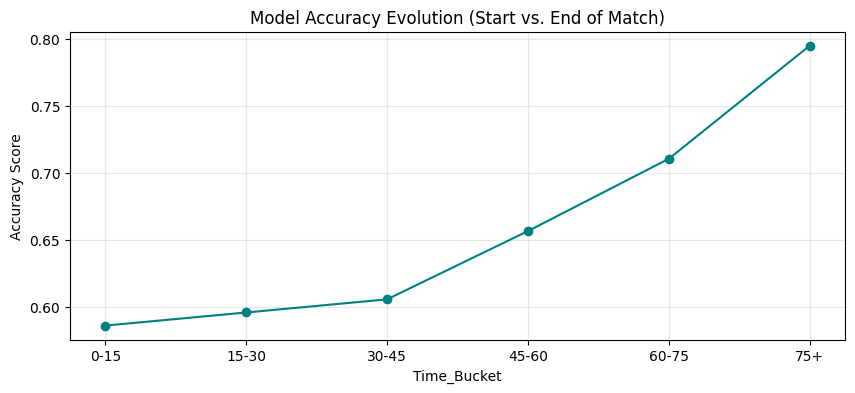

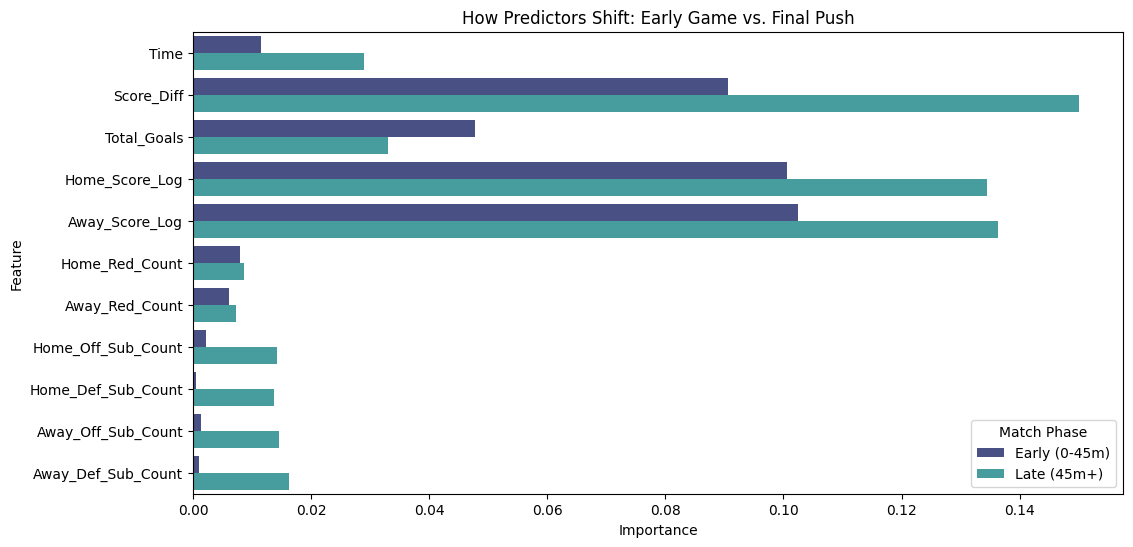


FINAL ANALYSIS:
The Accuracy plot confirms that predictions become significantly more reliable after
the 60th minute. The Cluster visualizations (Gray/Blue/Orange) provide the spatial
context, showing how SMOTE and Manhattan distance help differentiate 'Draw' patterns.


In [13]:
# STAGE 3: TIME-BASED & TIME-EVOLVING ANALYSIS
# =================================================================
print("\n--- Stage 3: Time-Evolving Feature Analysis ---")
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred_smote
bins = [0, 15, 30, 45, 60, 75, 100]
labels = ['0-15', '15-30', '30-45', '45-60', '60-75', '75+']
results_df['Time_Bucket'] = pd.cut(results_df['Time'], bins=bins, labels=labels)

time_perf = results_df.groupby('Time_Bucket', observed=False).apply(
    lambda x: accuracy_score(x['Actual'], x['Predicted'])
)

plt.figure(figsize=(10, 4))
time_perf.plot(kind='line', marker='o', color='teal')
plt.title("Model Accuracy Evolution (Start vs. End of Match)")
plt.ylabel("Accuracy Score")
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance: Early vs Late
early_mask = X_test['Time'] <= 45
late_mask = X_test['Time'] > 45
imp_early = permutation_importance(best_model, X_test[early_mask], y_test[early_mask], n_repeats=5, random_state=42)
imp_late = permutation_importance(best_model, X_test[late_mask], y_test[late_mask], n_repeats=5, random_state=42)

importance_df = pd.DataFrame({
    'Feature': features,
    'Early (0-45m)': imp_early.importances_mean,
    'Late (45m+)': imp_late.importances_mean
}).melt(id_vars='Feature', var_name='Match Phase', value_name='Importance')

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Match Phase', palette='mako')
plt.title("How Predictors Shift: Early Game vs. Final Push")
plt.show()

print("\nFINAL ANALYSIS:")
print("The Accuracy plot confirms that predictions become significantly more reliable after")
print("the 60th minute. The Cluster visualizations (Gray/Blue/Orange) provide the spatial")
print("context, showing how SMOTE and Manhattan distance help differentiate 'Draw' patterns.")